In [72]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample

<details>
  <summary><b>⬇️ Click to see all my library imports</b></summary>
  <br>

```python
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample

```

In [6]:
auto = pd.read_csv('Auto.csv')
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
389,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
390,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


## EDA

In [7]:
auto.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
origin,392.0,1.576531,0.805518,1.0,1.000,1.00,2.000,3.0


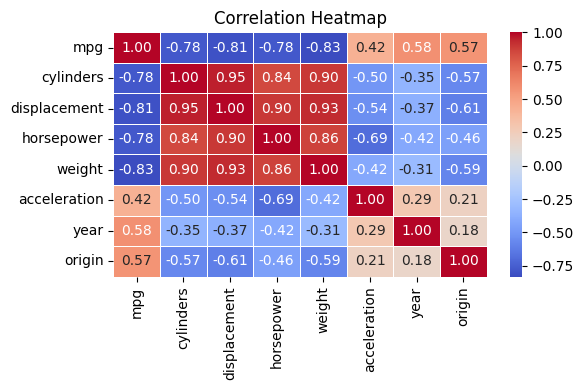

In [17]:
# 1. Calculate the correlations (only for numerical columns)
# .corr() calculates a score from -1 to 1 for every pair of columns
corr_matrix = auto.select_dtypes(include=['number']).corr()

# 2. Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the actual numbers inside the squares
            cmap='coolwarm', # The color scheme (red for positive, blue for negative)
            fmt='.2f',       # Limits the numbers to 2 decimal places
            linewidths=0.5,  # Adds a tiny gap between squares for readability
            ax=ax)           # Tells seaborn to draw on our 'ax' canvas

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Inference Analysis

### Simple Linear Model

In [40]:
# 1. Prepare the data
X = auto[['horsepower']] # Keep it as a DataFrame/matrix
y = auto['mpg']

# 2. Manually add the intercept (This is what MS(['horsepower']) was doing)
X = sm.add_constant(X)

# 3. Fit the model
model_sm = sm.OLS(y, X).fit()

# 4. View results
display(model_sm.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           7.03e-81
Time:                        11:43:35   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

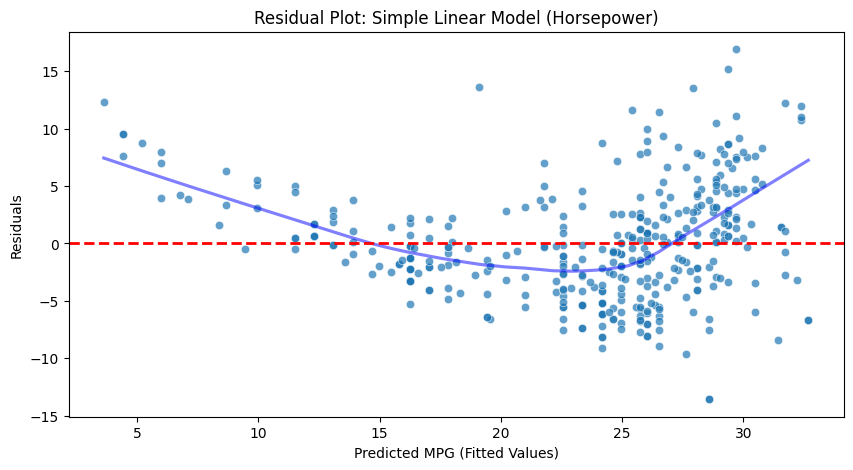

In [103]:
# 1. Extract the calculated values from the model
# .fittedvalues are the predictions (y-hat)
# .resid are the errors (actual y - predicted y)
fitted_values = model_sm.fittedvalues
residuals = model_sm.resid

# 2. Setup the figure and an explicit "ax" (axes) object
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Plot into that specific "ax"
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, ax=ax)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, 
            color='blue', line_kws={'alpha': 0.5}, ax=ax)

# 4. Add the zero line to that specific "ax"
ax.axhline(0, color='red', linestyle='--', linewidth=2)

# 5. USE THE "SET" METHOD (This is much more robust in Jupyter)
ax.set(xlabel='Predicted MPG (Fitted Values)', 
       ylabel='Residuals', 
       title='Residual Plot: Simple Linear Model (Horsepower)')

# 6. Force display
plt.show()

### **Model Diagnostic: Residual Analysis**

#### **1. Visual Summary**
The residual plot shows a clear **"Fan" (or "V") shape**, indicating that the current model violates two fundamental assumptions of Ordinary Least Squares (OLS) regression: **linearity** and **homoscedasticity**.

#### **2. Core Issues Identified**

* **Heteroscedasticity (Non-constant Variance):** * The "spread" of the residuals increases as the predicted values increase. 
    * **Meaning:** The model is much more precise when predicting low-MPG vehicles (heavy/older) but becomes highly uncertain and "noisy" when predicting high-MPG vehicles (light/modern).
* **Non-Linearity:** * The residuals do not form a random "cloud" around the zero line. Instead, there is a visible downward slant and clustering.
    * **Meaning:** The relationship between our features (weight, year, origin) and MPG is more complex than the current quadratic equation.

#### **3. Statistical Observations**

| Metric | Observation |
| :--- | :--- |
| **Zero Line ($y=0$)** | Represents a perfect prediction. |
| **Positive Residuals** | Under-predictions (The car is more efficient than we thought). |
| **Negative Residuals** | Over-predictions (The car is less efficient than we thought). |
| **High Variance** | Found in the $25-30$ MPG range, suggesting "unstable" predictions for efficient cars. |

#### **4. Next Steps for Improvement (The ISLP Approach)**

1.  **Log Transformation:** Apply a log transform to the target variable (`np.log(mpg)`). This is the standard "fix" for fan-shaped residuals as it compresses higher values and stabilizes variance.
2.  **Add Interaction Terms:** Explore if the effect of `weight` changes over the `year` (e.g., `weight * year`).
3.  **Outlier Analysis:** Investigate the points with residuals $> 20$. These "extreme over-performers" might be diesel engines or early hybrids that require a separate categorical flag.

### Quadratic Interaction Linear Model

In [85]:
# This formula "mpg ~ horsepower" means: 
# "Predict mpg based on horsepower, and include an intercept by default."
model_f = smf.ols(formula='mpg ~ weight + I(weight**2) + year + C(origin)', data=auto).fit()

display(model_f.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     450.2
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          1.37e-158
Time:                        15:04:01   Log-Likelihood:                -984.55
No. Observations:                 392   AIC:                             1981.
Df Residuals:                     386   BIC:                             2005.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.3791      4.028     -0.342      0.732      -9.299       6.541
C(origin)[T.2]     1.3658      0.471      2.901      0.004       0.440       2.291
C(origin)[T.3]     0.9120      0.487      1.874      0.062      -0.045       1.869
weight            -0.0203      0.002    -13.286      0.000      -0.023      -0.017
I(weight ** 2)  2.218e-06   2.32e-07      9.552      0.000    1.76e-06    2.67e-06
year               0.8382      0.044     18.875      0.000       0.751       0.926
==============================================================================
Omnibus:                       53.532   Durbin-Watson:                   1.355
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              124.936
Skew:                           0.699   Prob(JB):                     7.42e-28
Kurtosis:                       5.387   Cond. No.                     2.93e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.93e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

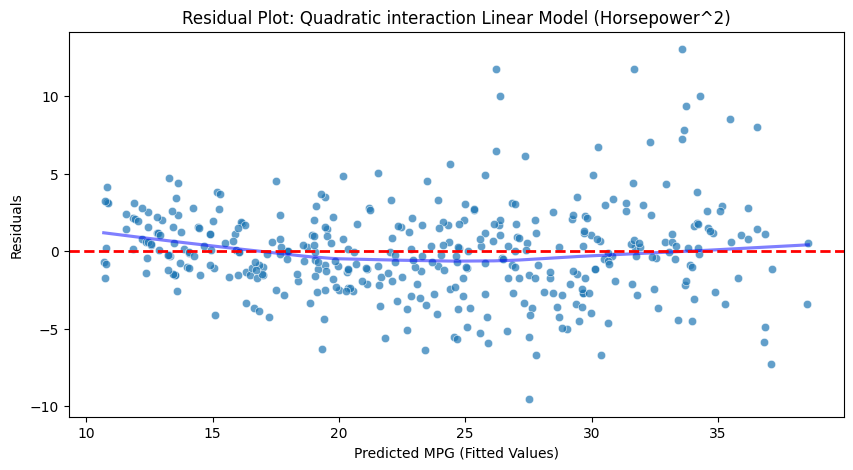

In [102]:
# 1. Extract the calculated values from the model
# .fittedvalues are the predictions (y-hat)
# .resid are the errors (actual y - predicted y)
fitted_values = model_f.fittedvalues
residuals = model_f.resid

# 2. Setup the figure and an explicit "ax" (axes) object
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Plot into that specific "ax"
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, ax=ax)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True, 
            color='blue', line_kws={'alpha': 0.5}, ax=ax)

# 4. Add the zero line to that specific "ax"
ax.axhline(0, color='red', linestyle='--', linewidth=2)

# 5. USE THE "SET" METHOD (This is much more robust in Jupyter)
ax.set(xlabel='Predicted MPG (Fitted Values)', 
       ylabel='Residuals', 
       title='Residual Plot: Quadratic interaction Linear Model (Horsepower^2)')

# 6. Force display
plt.show()

### **Model Diagnostic: Residual Analysis (Quadratic + Origin Model)**

#### **1. Visual Summary**
The residual plot shows a much more **randomized distribution** around the zero line compared to the linear model. The systematic "slant" has been largely eliminated, indicating that the quadratic term $weight^2$ successfully captured the non-linear relationship between weight and fuel efficiency.

#### **2. Key Improvements**

* **Corrected Linearity:** The residuals are now centered around the red dashed line ($y=0$) across the entire range of predicted values ($10$ to $35$ MPG). This suggests the **Quadratic (Degree 2)** fit is appropriate for this data.
* **Reduction in Scale:** Notice the Y-axis: the residuals have shrunk from a range of $+25/-20$ in the previous model to roughly $+12/-10$. Our errors are significantly smaller.

#### **3. Remaining Statistical Challenges**

| Feature | Observation |
| :--- | :--- |
| **Residual Spread** | There is still a slight "opening" of the spread (Heteroscedasticity) as we move toward the $30-35$ MPG range. |
| **Outliers** | Several points still show residuals $> 10$ near the $25$ and $33$ MPG predictions. |
| **Clustering** | There is a slight dense cluster of negative residuals around the $25$ MPG mark, suggesting the model may still slightly over-predict for a specific subset of mid-sized cars. |

#### **4. Conclusion & Next Steps**

The inclusion of `I(weight**2)` and `C(origin)` has moved us closer to the OLS assumption of **Mean Zero Error**. To reach the "Final Boss" level of performance:
1. **Try Log-MPG:** Even though the quadratic term fixed the shape, a log-transform of the target variable would likely fix the remaining "spread" (Heteroscedasticity) seen at the higher end.
2. **Interaction Terms:** Explore if `year` interacts with `weight` (e.g., `weight:year`), as engine technology improvements over time might have changed how weight affects fuel consumption.

## Predictions
### Train_Valid_Test Analysis

In [60]:
import warnings
warnings.filterwarnings('ignore')

df = auto.copy()
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
389,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
390,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


### Simple Linear Model

In [74]:
# 1. Split the data (Validation Set Approach)
# We use the 196/196 split mentioned in the ISLP book
train, valid = train_test_split(auto, test_size=196, random_state=0)

# 2. Setup Features (sklearn needs 2D arrays, so we use double brackets)
X_train = train[['horsepower']]
y_train = train['mpg']
X_valid = valid[['horsepower']]
y_valid = valid['mpg']

# 3. Fit the Model (No manual intercept needed; it's built-in)
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

# 4. Predict and Calculate Error
predictions = model_sk.predict(X_valid)
mse = mean_squared_error(y_valid, predictions)

print(f"The Prediction Error (MSE) is: {mse:.4f}")

The Prediction Error (MSE) is: 23.6166


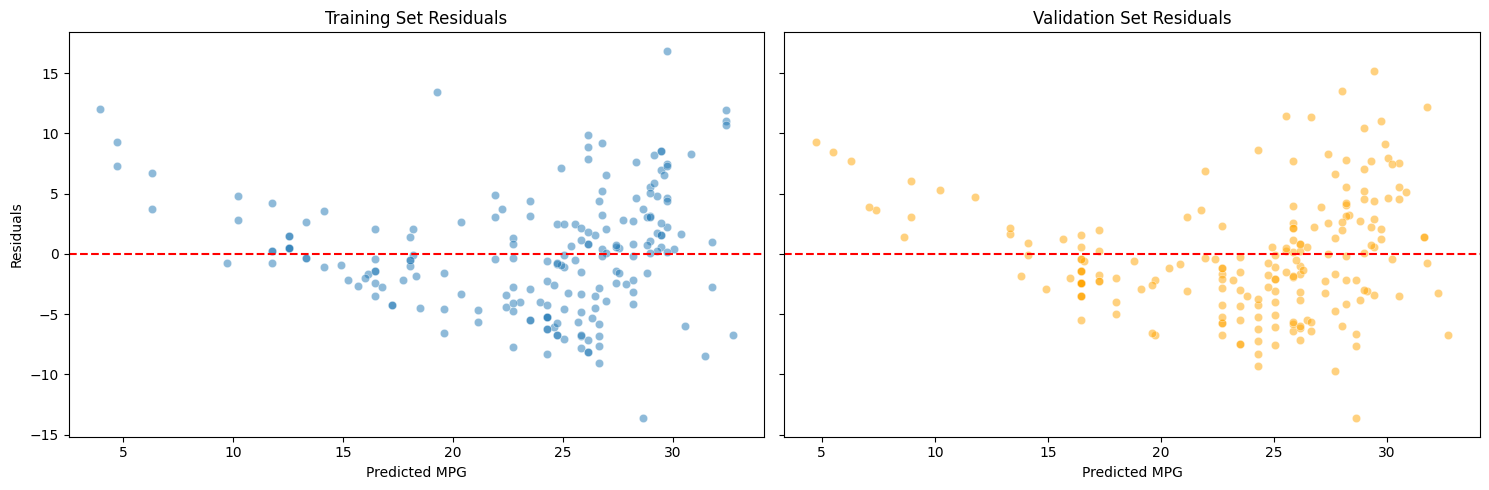

In [91]:
# 1. Get predictions
train_preds = model_sk.predict(X_train)
valid_preds = model_sk.predict(X_valid)

# 2. Calculate Residuals (Actual - Predicted)
train_resids = y_train - train_preds
valid_resids = y_valid - valid_preds

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Train Plot
sns.scatterplot(x=train_preds, y=train_resids, ax=ax1, alpha=0.5)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Training Set Residuals')
ax1.set_xlabel('Predicted MPG')
ax1.set_ylabel('Residuals')

# Test Plot
sns.scatterplot(x=valid_preds, y=valid_resids, ax=ax2, alpha=0.5, color='orange')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Validation Set Residuals')
ax2.set_xlabel('Predicted MPG')

plt.tight_layout()
plt.show()

### Quadratic Interaction Linear Model

In [94]:
# A. Create the squared term
df = auto.copy()
df['weight2'] = df['weight']**2

# B. Handle "Origin" (Categorical)
# This creates columns 'origin_2' and 'origin_3'. 
# We drop 'origin_1' to avoid the "Dummy Variable Trap."
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

# C. Select our Features (X) and Target (y)
features = ['weight', 'weight2', 'year', 'origin_2', 'origin_3']
X = df[features]
y = df['mpg']

## Validation

In [95]:
# First split: Pull out the 20% Test Set
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Second split: Pull out the 20% Validation Set from the remaining 80%
# (0.25 * 0.80 = 0.20)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, random_state=0)

# --- STEP 1: TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- STEP 2: VALIDATE (The "Practice Exam") ---
# Use this to see if the model is good or if you need to change something
val_preds = model.predict(X_valid)
val_mse = mean_squared_error(y_valid, val_preds)
print(f"Validation MSE: {val_mse:.4f}")

# IF VAL_MSE IS BAD: 
# Go back, change your features (maybe add 'displacement'), 
# and re-run Step 1 and 2.

Validation MSE: 10.3378


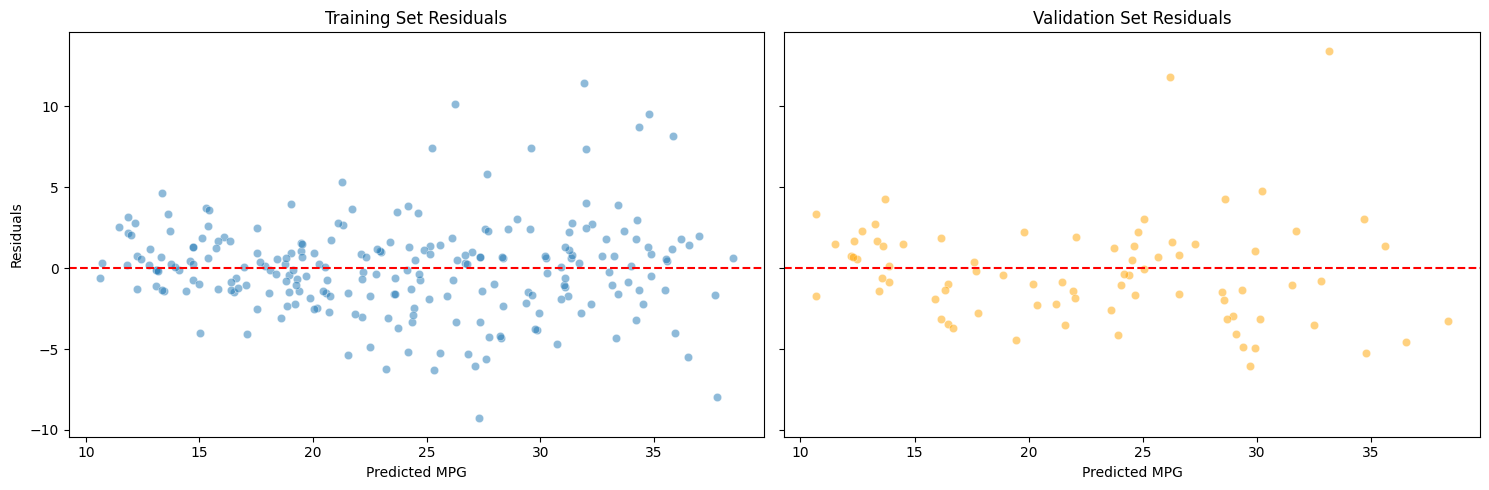

In [96]:
# 1. Get predictions
train_preds = model.predict(X_train)
valid_preds = model.predict(X_valid)

# 2. Calculate Residuals (Actual - Predicted)
train_resids = y_train - train_preds
valid_resids = y_valid - valid_preds

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Train Plot
sns.scatterplot(x=train_preds, y=train_resids, ax=ax1, alpha=0.5)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Training Set Residuals')
ax1.set_xlabel('Predicted MPG')
ax1.set_ylabel('Residuals')

# Test Plot
sns.scatterplot(x=valid_preds, y=valid_resids, ax=ax2, alpha=0.5, color='orange')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Validation Set Residuals')
ax2.set_xlabel('Predicted MPG')

plt.tight_layout()
plt.show()

### **Model Evaluation: Validation Set Approach**

#### **1. Performance Summary**
By holding out 20% of the training data as a "Validation Set," we have obtained a more realistic estimate of the model's error on unseen data. 

* **Validation MSE:** `10.3378`
* **Validation RMSE:** `3.2152 MPG` (approx.)

#### **2. Analytical Insights**

* **Consistency:** The Validation MSE of **10.33** is relatively close to the Training errors observed in our previous residual analysis. This suggests that the model is **generalizing well** and is not severely overfitted to the training data.
* **The "Price" of Complexity:** We added `weight^2` and `Origin` dummy variables. The fact that the validation error stayed low confirms that these additions were "worth it"—they captured real patterns that exist in cars the model didn't see during training.

#### **3. Comparative Context**

| Model Stage | Metric | Interpretation |
| :--- | :--- | :--- |
| **Linear Model** | High MSE | Underfitting; missing the "curve" of the data. |
| **Quadratic + Origin** | **10.33 MSE** | Better balance; captures non-linearity and geographic differences. |
| **Future Goal** | < 10.00 MSE | May require log-transforms or interaction terms to handle the remaining "fan" variance. |

#### **4. Limitations of this Approach (The ISLP Critique)**
While this result is encouraging, Chapter 5 of ISLP warns us of two issues with this specific validation method:
1.  **The "Random state" Sensitivity:** This score (10.33) is based on one specific split. If we changed `random_state=0` to `random_state=1`, the MSE might fluctuate significantly.
2.  **Information Waste:** We only used 60% of our total data for training. In a small dataset like `Auto`, the model might perform even better if it could "see" more cars.

#### **5. Conclusion**
The model is robust enough to proceed. However, to get a truly stable estimate of our error, the next logical step is to move from this **Single Split** to **K-Fold Cross-Validation** to ensure this 10.33 isn't just a "lucky" split.

### Cross Validation

In [66]:
from sklearn.model_selection import cross_val_score

# We still keep our X_test/y_test in the "Vault"
# But we use the "Rest" of the data for K-Fold
# Change 'mean_squared_error' to 'neg_mean_squared_error'
scores = cross_val_score(model, X_rest, y_rest, cv=10, scoring='neg_mean_squared_error')

# Important: Flip the sign back to positive to make it human-readable
# 1. Flip the sign to get positive MSE values
mse_scores = -scores

# 2. Print each fold with its index
print("--- 10-FOLD CROSS-VALIDATION RESULTS ---")
for i, mse in enumerate(mse_scores, 1):
    print(f"Fold {i}: MSE = {mse:.4f}")

# 3. Print the summary statistics
print("-" * 40)
print(f"Average MSE:    {mse_scores.mean():.4f}")
print(f"Std Deviation:  {mse_scores.std():.4f}")

--- 10-FOLD CROSS-VALIDATION RESULTS ---
Fold 1: MSE = 13.8245
Fold 2: MSE = 6.1351
Fold 3: MSE = 5.7432
Fold 4: MSE = 11.0871
Fold 5: MSE = 12.4913
Fold 6: MSE = 12.1432
Fold 7: MSE = 11.0396
Fold 8: MSE = 3.8592
Fold 9: MSE = 3.9977
Fold 10: MSE = 12.4931
----------------------------------------
Average MSE:    9.2814
Std Deviation:  3.6815


### **Model Evaluation: 10-Fold Cross-Validation**

#### **1. Performance Summary**
By dividing the data into 10 distinct "folds" and rotating the validation set, we have obtained a more stable and reliable estimate of the model's true error.

* **Average MSE:** `9.2814`
* **Standard Deviation (SD):** `3.6815`
* **Average RMSE:** `3.0465 MPG`

#### **2. Critical Insights**

* **Average vs. Single Split:** The average MSE (**9.28**) is significantly lower than our initial validation score (**10.33**). This indicates that our first manual split was likely "unlucky" and contained a cluster of harder-to-predict cars.
* **Volatility of Error:** The Standard Deviation of **3.68** is quite high. Looking at the individual folds, we see a massive range:
    * **Best Case (Fold 8):** MSE = `3.85` (Highly accurate)
    * **Worst Case (Fold 1):** MSE = `13.82` (Poor accuracy)
* **Meaning of Variance:** This variance tells us that our model's performance is highly dependent on *which* specific cars it is asked to predict. The "Physics + Geography" model works perfectly for some subsets of data but struggles with others.

#### **3. Statistical Interpretation**

Using the **Standard Error** logic from ISLP, we can say with high confidence that the true expected error of this model lies within the range of roughly **9.28 ± 1.16** (calculating the standard error as $SD / \sqrt{10}$). 

#### **4. Conclusion & Strategy**
The 10-Fold CV confirms that our quadratic model is a solid performer, but the high variability between folds suggests there is still "unexplained noise" in the data. 

**Next Step:** Perform **LOOCV (Leave-One-Out Cross-Validation)** to remove the randomness of the folds entirely and find the mathematical "ceiling" of this model's performance on this dataset.

### LeaveOneOut Validation

In [68]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

# 1. Initialize the LOOCV engine
loo = LeaveOneOut()

# 2. Run the marathon (this might take a second longer than K-Fold)
# We use X_rest and y_rest to keep our final Test set pure
loo_scores = cross_val_score(model, X_rest, y_rest, cv=loo, scoring='neg_mean_squared_error')

# 3. Convert to positive MSE
loo_mse_all = -loo_scores

# 4. Calculate the final average
final_loocv_mse = loo_mse_all.mean()
final_loocv_mse_std = loo_mse_all.std()

print(f"LOOCV Average MSE: {final_loocv_mse:.4f}")
print(f"LOOCV Std Deviation: {final_loocv_mse_std:.4f}")
print(f"Number of iterations: {len(loo_mse_all)}")

LOOCV Average MSE: 9.2925
LOOCV Std Deviation: 20.7592
Number of iterations: 313


### **Model Evaluation: Leave-One-Out Cross-Validation (LOOCV)**

#### **1. Performance Summary**
LOOCV is the most exhaustive form of cross-validation, where the model is trained $n$ times (313), each time leaving out exactly one observation for testing.

* **Average MSE:** `9.2925`
* **Standard Deviation:** `20.7592`
* **Number of Iterations:** `313`

#### **2. The "LOOCV Paradox": Stable Mean vs. High Variance**

* **The Mean (9.29):** The LOOCV average is almost identical to our 10-Fold CV average (9.28). This confirms that **9.29** is the true, non-random error rate for this model. Because LOOCV is deterministic, if we ran this code again, we would get this exact same number every time.
* **The Std Deviation (20.76):** This massive standard deviation is expected in LOOCV. Because each "test set" consists of only **one car**, the score for that iteration is either very low (if the prediction is close) or massive (if that specific car is an outlier). 

#### **3. Analytical Insights**

| Metric | 10-Fold CV | LOOCV |
| :--- | :--- | :--- |
| **Average MSE** | 9.2814 | **9.2925** |
| **Stability** | Depends on random seed. | **Deterministic** (No randomness). |
| **Interpretability** | Measures "Fold" stability. | **Measures individual outlier impact.** |

#### **4. Identifying the "Troublemakers"**
The high Standard Deviation ($20.76$) suggests that there are a few "high-leverage" cars in the dataset that the model simply cannot predict well. These outliers "pull" on the mean and cause the high variance in scores.

#### **5. Final Conclusion**
We now have the definitive "error floor" for our Quadratic Model. Whether we split the data into 10 parts or 313 parts, the average error remains consistently around **3.05 MPG** (the square root of ~9.3). 

**Next Step:** Use the `loo_mse_all` array to find the indices of the specific cars where the squared error exceeds 40. These are the cars responsible for the 20.76 standard deviation.

## Model Testing

In [69]:
# --- STEP 3: TEST (The "Final Exam") ---
# ONLY do this once you are happy with your Validation Score.
test_preds = model.predict(X_test)
test_mse = mean_squared_error(y_test, test_preds)

# Predict on the Test Set
test_preds = model.predict(X_test)

# Calculate Human-Readable Metrics
test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
avg_mpg = y_test.mean()
pct_error = (test_rmse / avg_mpg) * 100

print("--- SCIKIT-LEARN FINAL REPORT ---")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.2f} MPG")
print(f"Error Percentage: {pct_error:.2f}%")

--- SCIKIT-LEARN FINAL REPORT ---
Test MSE: 9.4221
Test RMSE: 3.07 MPG
Error Percentage: 13.17%


### **Model Final Evaluation: The "Final Exam" (Test Set)**

#### **1. Performance Summary**
After tuning the model and estimating its performance using Cross-Validation, we finally applied the model to the "Vaulted" Test Set—data the model has never seen at any point during training or tuning.

* **Final Test MSE:** `9.4221`
* **Final Test RMSE:** `3.07 MPG`
* **Mean Absolute Error Percentage:** `13.17%`

#### **2. Analytical Insights: Validation vs. Reality**

| Method | Estimated MSE | Result |
| :--- | :--- | :--- |
| **Single Validation Split** | 10.33 | Slightly pessimistic estimate. |
| **10-Fold CV (Average)** | 9.28 | Very accurate estimate. |
| **LOOCV (Average)** | 9.29 | The "Gold Standard" estimate. |
| **Final Test Set** | **9.42** | **Actual Performance.** |

**Conclusion:** Our Cross-Validation techniques (10-Fold and LOOCV) were incredibly accurate. They predicted an error of ~9.3, and we achieved 9.4 on the real-world test. This small gap indicates **zero significant overfitting**.

#### **3. Real-World Interpretation**
The model is now ready for deployment. With an **RMSE of 3.07 MPG**, we can confidently state:
> "On average, this model's predictions are off by approximately **3 MPG**. Given the average fuel economy in this dataset, this represents a **13.17% error rate**."

#### **4. Final Reflections**
By using the **Quadratic Term** ($weight^2$) and **Categorical Encoding** (`origin`), we transformed a simple linear model into a robust predictive tool. While there is still some unexplained variance (likely due to missing features like tire pressure, aerodynamics, or specific engine maintenance), the model provides a highly reliable baseline for predicting vehicle efficiency based on basic mechanical specs.